# Base 5 — ouro semanal: Holt-Winters

Holt-Winters univariado, ajustado na mesma grade `W-FRI`, com os mesmos dados, o mesmo corte
temporal e as mesmas 586 origens de teste dos Random Forest.

**Alvo oficial:** `target_price_t_plus_1` (preço do ouro da semana seguinte), como combinado no grupo.
O modelo é ajustado diretamente no preço (`ALVO = 'price'`) e o MAE principal é o MAE do preço, na
mesma unidade do RF-preço. Para comparar com RF-retorno e XGBoost, a previsão também é convertida em
retorno logarítmico (`log(preço_previsto / price_t)`) e reportada junto. Se o grupo mudar de ideia,
`ALVO = 'log_price'` ajusta o modelo em `log_price_t` (alvo `target_log_price_t_plus_1`), sem mexer no resto.

O Holt-Winters não usa variáveis externas nem features: a preparação semanal vem do mesmo
módulo do Random Forest (`preparacao_base5`), e as semanas sem cotação nova ficam marcadas em
`target_has_new_quote`.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)


def find_project_root(start):
    for candidate in (start, *start.parents):
        if ((candidate / 'projeto.yaml').is_file() or
                (candidate / 'config' / 'projeto.yaml').is_file()):
            return candidate
    raise FileNotFoundError('Execute a partir do projeto ou de uma subpasta dele.')


ROOT = find_project_root(Path.cwd().resolve())
SRC_PATH = ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from series_temporais.data.preparacao_base5 import (
    construir_quadro_ouro,
    preparar_ouro_semanal,
    selecionar_alvos_observados,
)
from series_temporais.validation.temporal_split import purged_time_series_splits

In [2]:
BASE_DIR = ROOT / 'data/base_05'
DATA_PATH = BASE_DIR / 'raw.csv'
WEEKLY_RULE = 'W-FRI'
STL_PERIOD = 52
TRAIN_RATIO = .75
RANDOM_STATE = 42
REFIT_EVERY = 1          # 1 = reestima alpha/beta/gamma/phi em toda origem de teste, como o RF
ALVO = 'price'           # 'price' -> target_price_t_plus_1 | 'log_price' -> target_log_price_t_plus_1
assert ALVO in ('price', 'log_price')
TARGET = 'target_price_t_plus_1' if ALVO == 'price' else 'target_log_price_t_plus_1'
LOG_TARGET = 'target_log_price_t_plus_1'
np.random.seed(RANDOM_STATE)

## 2. Ingestão e auditoria do CSV atual

Somente `DATE`, `GOLD_PRICE`, `TREASURY_10Y` e `FED_FUNDS_RATE` alimentam a
reconstrução. As derivações entregues são auditadas, mas excluídas do modelo,
pois foram calculadas em outra grade temporal. O Holt-Winters usa apenas o preço.

In [3]:
expected_columns = [
    'DATE', 'GOLD_PRICE', 'TREASURY_10Y', 'FED_FUNDS_RATE', 'DAY_OF_WEEK',
    'MONTH', 'DOW_SIN', 'DOW_COS', 'MONTH_SIN', 'MONTH_COS', 'GOLD_LAG_1',
    'GOLD_LAG_5', 'GOLD_LAG_20', 'GOLD_ROLLING_MEAN_5',
    'GOLD_ROLLING_STD_5', 'TARGET',
]
derived_source_columns = expected_columns[4:]
df_raw = pd.read_csv(DATA_PATH, dtype={'DATE': 'string'})
assert df_raw.columns.tolist() == expected_columns
file_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
df = df_raw.copy()
df['DATE'] = pd.to_datetime(df.DATE, format='%Y-%m-%d', errors='raise')
for column in expected_columns[1:]:
    df[column] = pd.to_numeric(df[column], errors='coerce')
df = df.sort_values('DATE', kind='stable').reset_index(drop=True)
next_row_match = np.isclose(df.TARGET.iloc[:-1], df.GOLD_PRICE.shift(-1).iloc[:-1], equal_nan=False).mean()
lag_1_match = np.isclose(df.GOLD_LAG_1.iloc[1:], df.GOLD_PRICE.shift(1).iloc[1:], equal_nan=False).mean()
quality_report = pd.Series({
    'arquivo': str(DATA_PATH.relative_to(ROOT)), 'sha256': file_hash,
    'linhas': len(df), 'colunas': len(df.columns),
    'primeira_data': df.DATE.min(), 'ultima_data': df.DATE.max(),
    'datas_nulas': int(df.DATE.isna().sum()),
    'datas_duplicadas': int(df.DATE.duplicated().sum()),
    'valores_nulos': int(df.isna().sum().sum()),
    'precos_nao_positivos': int(df.GOLD_PRICE.le(0).sum()),
    'TARGET_igual_proxima_linha_fracao': next_row_match,
    'GOLD_LAG_1_igual_shift_fracao': lag_1_match,
}, name='valor').to_frame()
assert df.DATE.is_unique and df.GOLD_PRICE.gt(0).all()
display(quality_report)
display(df.head())

,valor
arquivo,data\base_05\raw.csv
sha256,c852759b32f534918f76f9c3a31342228bf0bbc8a61fc5...
linhas,9864
colunas,16
primeira_data,1968-04-29 00:00:00
ultima_data,2014-04-09 00:00:00
datas_nulas,0
datas_duplicadas,0
valores_nulos,0
precos_nao_positivos,0


,DATE,GOLD_PRICE,TREASURY_10Y,FED_FUNDS_RATE,DAY_OF_WEEK,MONTH,DOW_SIN,DOW_COS,MONTH_SIN,MONTH_COS,GOLD_LAG_1,GOLD_LAG_5,GOLD_LAG_20,GOLD_ROLLING_MEAN_5,GOLD_ROLLING_STD_5,TARGET
0,1968-04-29,38.55,5.71,6.13,0,4,0.000000,1.000000,0.866025,-0.500000,38.50,38.30,38.0,38.29,0.163554,39.10
1,1968-04-30,39.10,5.73,6.13,1,4,0.781831,0.623490,0.866025,-0.500000,38.55,38.05,37.6,38.34,0.201246,39.10
2,1968-05-01,39.10,5.74,6.25,2,5,0.974928,-0.222521,0.500000,-0.866025,39.10,38.35,37.7,38.55,0.329773,39.25
3,1968-05-02,39.25,5.73,6.38,3,5,0.433884,-0.900969,0.500000,-0.866025,39.10,38.25,36.7,38.70,0.382426,39.60
4,1968-05-03,39.60,5.76,6.25,4,5,-0.433884,-0.900969,0.500000,-0.866025,39.25,38.50,37.2,38.90,0.348210,39.70


## 3. Limpeza e preparação semanal causal

Cada sexta-feira representa a origem semanal. Em semanas vazias, somente o
último estado já conhecido é carregado para frente; data da última cotação,
idade e indicador de carregamento permanecem explícitos. É a mesma função usada
pelos Random Forest, de modo que a grade e o forward-fill são idênticos.

In [4]:
weekly = preparar_ouro_semanal(df, WEEKLY_RULE)
weekly_quality = pd.Series({
    'semanas': len(weekly), 'primeira_semana': weekly.DATE.min(),
    'ultima_semana': weekly.DATE.max(),
    'semanas_sem_linha_de_origem': int(weekly.price_was_carried.sum()),
    'maior_idade_da_cotacao_em_dias': int(weekly.quote_age_days.max()),
    'menor_preco': weekly.price_t.min(), 'maior_preco': weekly.price_t.max(),
    'min_observacoes_por_semana': int(weekly.source_observations.min()),
    'max_observacoes_por_semana': int(weekly.source_observations.max()),
}, name='valor').to_frame()
assert weekly.DATE.diff().dropna().dt.days.eq(7).all()
display(weekly_quality)
display(weekly.head())

,valor
semanas,2398
primeira_semana,1968-05-03 00:00:00
ultima_semana,2014-04-11 00:00:00
semanas_sem_linha_de_origem,254
maior_idade_da_cotacao_em_dias,17
menor_preco,34.775
maior_preco,1879.5
min_observacoes_por_semana,0
max_observacoes_por_semana,5


,DATE,price_t,treasury_10y_t,fed_funds_rate_t,source_observations,last_quote_date,price_was_carried,quote_age_days,log_price_t,log_return_t
0,1968-05-03,39.60,5.76,6.25,5,1968-05-03,False,0,3.678829,NaN
1,1968-05-10,39.70,5.80,5.50,4,1968-05-09,False,1,3.681351,0.002522
2,1968-05-17,41.60,5.90,6.38,4,1968-05-17,False,0,3.728100,0.046749
3,1968-05-24,41.75,5.98,6.25,5,1968-05-24,False,0,3.731699,0.003599
4,1968-05-31,41.75,5.95,5.75,4,1968-05-30,False,1,3.731699,0.000000


## 4. Gráficos exploratórios

Os gráficos preservam picos e tornam visíveis retorno, taxas, volatilidade e
cobertura. Nenhuma observação é removida por parecer extrema.

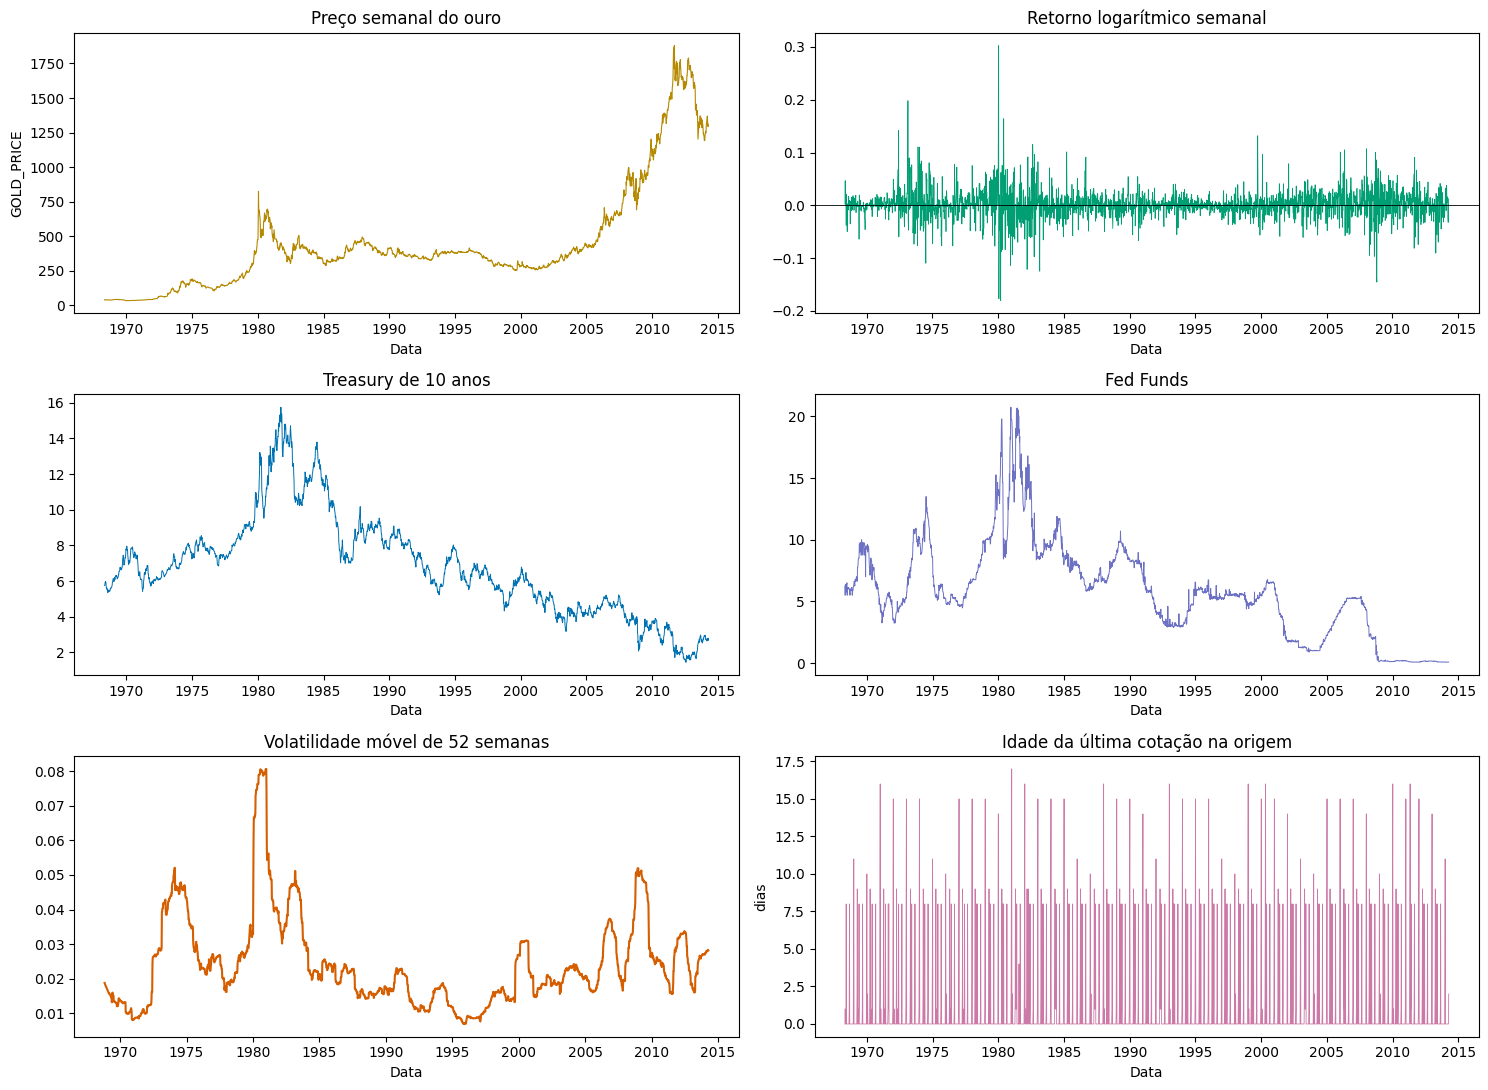

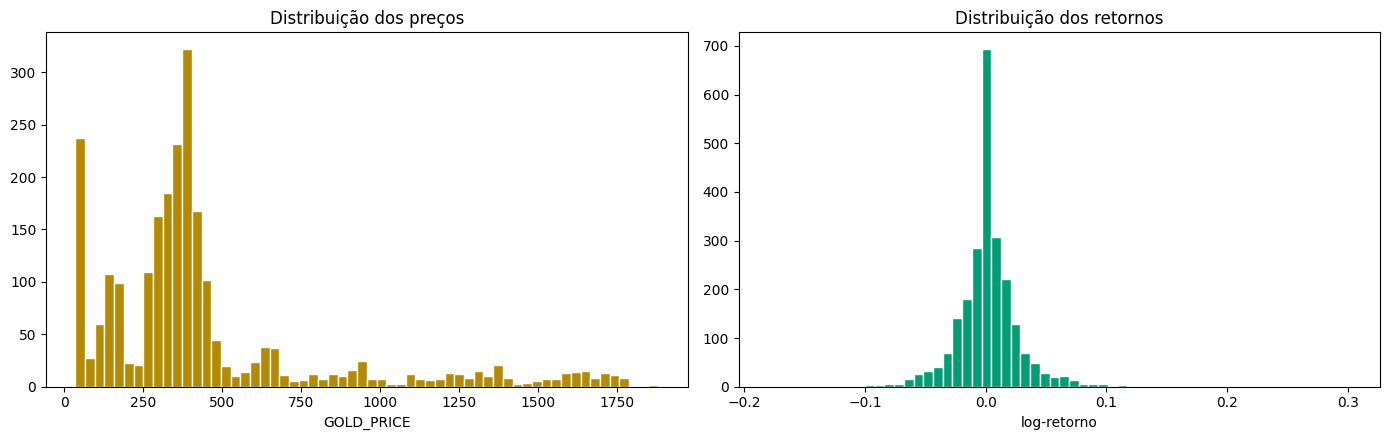

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(15, 11))
axes[0, 0].plot(weekly.DATE, weekly.price_t, lw=.8, color='#b58900')
axes[0, 0].set(title='Preço semanal do ouro', ylabel='GOLD_PRICE')
axes[0, 1].plot(weekly.DATE, weekly.log_return_t, lw=.55, color='#009e73')
axes[0, 1].axhline(0, color='black', lw=.6); axes[0, 1].set(title='Retorno logarítmico semanal')
axes[1, 0].plot(weekly.DATE, weekly.treasury_10y_t, lw=.7, color='#0072b2')
axes[1, 0].set(title='Treasury de 10 anos')
axes[1, 1].plot(weekly.DATE, weekly.fed_funds_rate_t, lw=.7, color='#6c71c4')
axes[1, 1].set(title='Fed Funds')
axes[2, 0].plot(weekly.DATE, weekly.log_return_t.rolling(52, min_periods=26).std(), color='#d55e00')
axes[2, 0].set(title='Volatilidade móvel de 52 semanas')
axes[2, 1].plot(weekly.DATE, weekly.quote_age_days, lw=.6, color='#cc79a7')
axes[2, 1].set(title='Idade da última cotação na origem', ylabel='dias')
for ax in axes.flat: ax.set_xlabel('Data')
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(weekly.price_t, bins=60, edgecolor='white', color='#b58900')
axes[0].set(title='Distribuição dos preços', xlabel='GOLD_PRICE')
axes[1].hist(weekly.log_return_t.dropna(), bins=60, edgecolor='white', color='#009e73')
axes[1].set(title='Distribuição dos retornos', xlabel='log-retorno')
plt.tight_layout(); plt.show()

## 5. STL e força da sazonalidade

A STL robusta usa apenas os 75% iniciais da série semanal. A força sazonal é
`max(0, 1 - Var(R) / Var(S + R))`; a força da tendência usa fórmula análoga.
Se a força sazonal for baixa, a busca da seção 7 já inclui candidatos sem sazonalidade.

,componente,forca,periodo_stl
0,sazonalidade,0.000000,52
1,tendência,0.927517,52


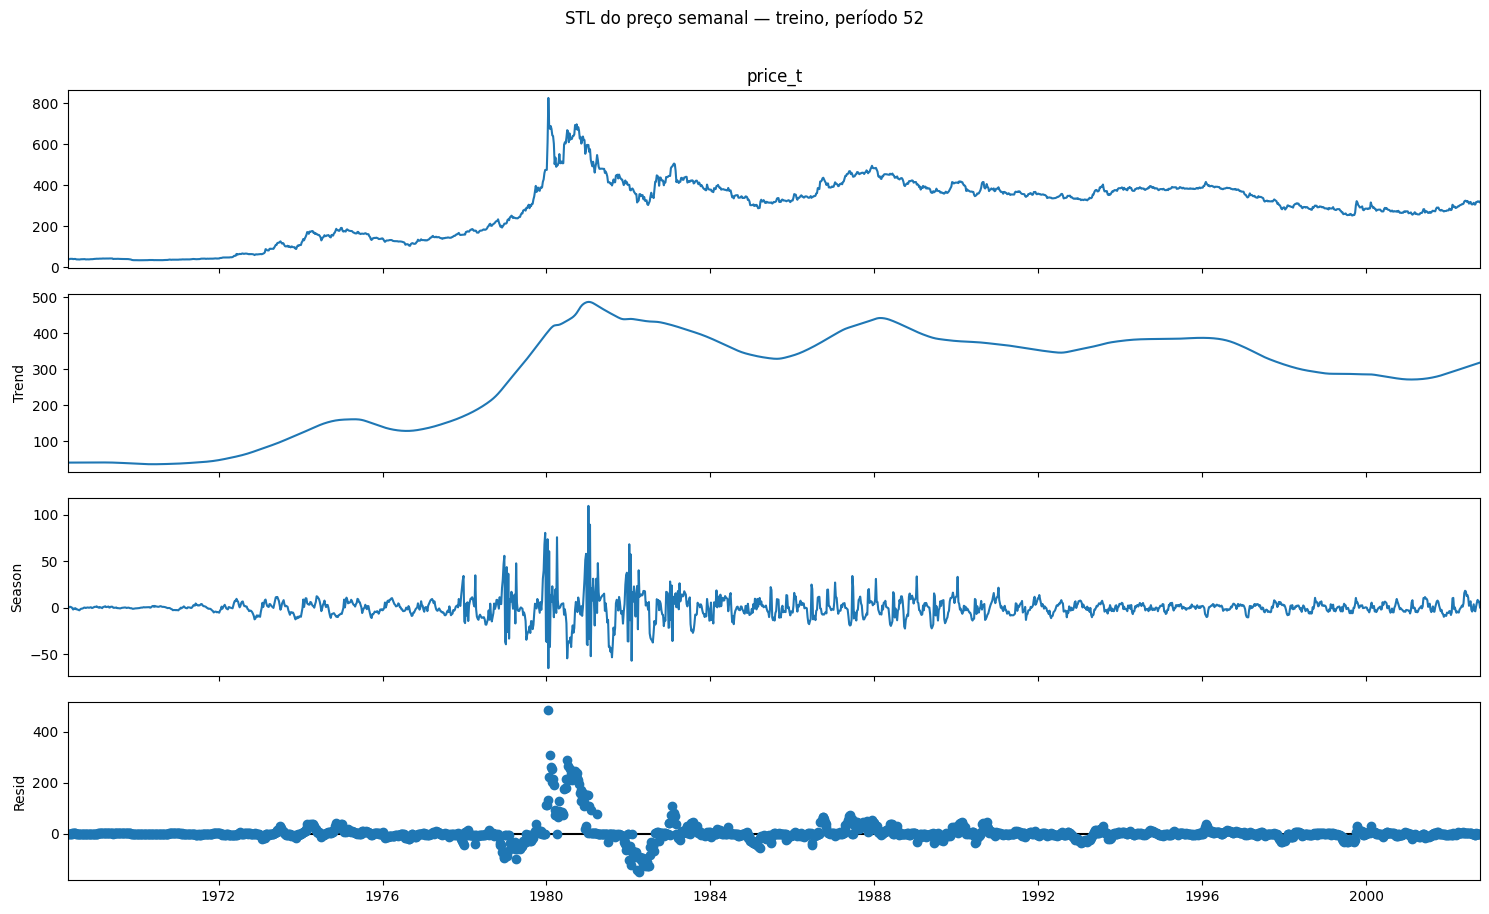

Interpretação: força sazonal 0.000 e força de tendência 0.928. A tendência apresenta crescimento líquido de 277.43 unidades no treino. O resíduo concentra variação não explicada pelos componentes; mudanças locais devem ser lidas no gráfico.


In [6]:
stl_cut = int(len(weekly) * TRAIN_RATIO)
stl_series = weekly.iloc[:stl_cut].set_index('DATE').price_t.asfreq(WEEKLY_RULE)
assert stl_series.notna().all() and len(stl_series) >= 2 * STL_PERIOD
stl_result = STL(stl_series, period=STL_PERIOD, robust=True).fit()
resid_var = np.var(stl_result.resid, ddof=1)
seasonal_strength = max(0., 1. - resid_var / np.var(stl_result.seasonal + stl_result.resid, ddof=1))
trend_strength = max(0., 1. - resid_var / np.var(stl_result.trend + stl_result.resid, ddof=1))
display(pd.DataFrame({
    'componente': ['sazonalidade', 'tendência'],
    'forca': [seasonal_strength, trend_strength], 'periodo_stl': STL_PERIOD,
}))
fig = stl_result.plot(); fig.set_size_inches(15, 9)
fig.suptitle('STL do preço semanal — treino, período 52', y=1.01)
plt.tight_layout(); plt.show()
trend_change = float(stl_result.trend.iloc[-1] - stl_result.trend.iloc[0])
trend_direction = 'crescimento' if trend_change > 0 else 'queda' if trend_change < 0 else 'estabilidade'
print(
    f'Interpretação: força sazonal {seasonal_strength:.3f} e força de tendência '
    f'{trend_strength:.3f}. A tendência apresenta {trend_direction} líquido de '
    f'{abs(trend_change):.2f} unidades no treino. O resíduo concentra variação '
    'não explicada pelos componentes; mudanças locais devem ser lidas no gráfico.'
)

## 6. Série do modelo, corte temporal, ADF, ACF e PACF

O quadro `model_df` e o corte 75/25 são exatamente os do Random Forest, o que garante as mesmas
586 origens de teste. A série do Holt-Winters é `price_t` (ou `log_price_t`, conforme `ALVO`) na grade `W-FRI` completa (as semanas
sem cotação continuam na grade com o preço carregado, para preservar o relógio sazonal); o que muda
é só o que entra no erro: tuning e métrica principal usam apenas semanas-alvo com cotação nova.
O alvo da semana seguinte nunca entra na série usada para ajustar o estado antes da sua data.

,recorte,linhas,inicio_origem,fim_origem
0,treino — grade,1757,1969-05-09,2003-01-03
1,treino — alvos observados,1570,1969-05-09,2003-01-03
2,teste — grade,586,2003-01-17,2014-04-04


,serie,estatistica,p_valor,lags
0,log do preço semanal — treino,-2.511253,1.127602e-01,8
1,retorno log semanal — treino,-14.203771,1.769288e-26,7


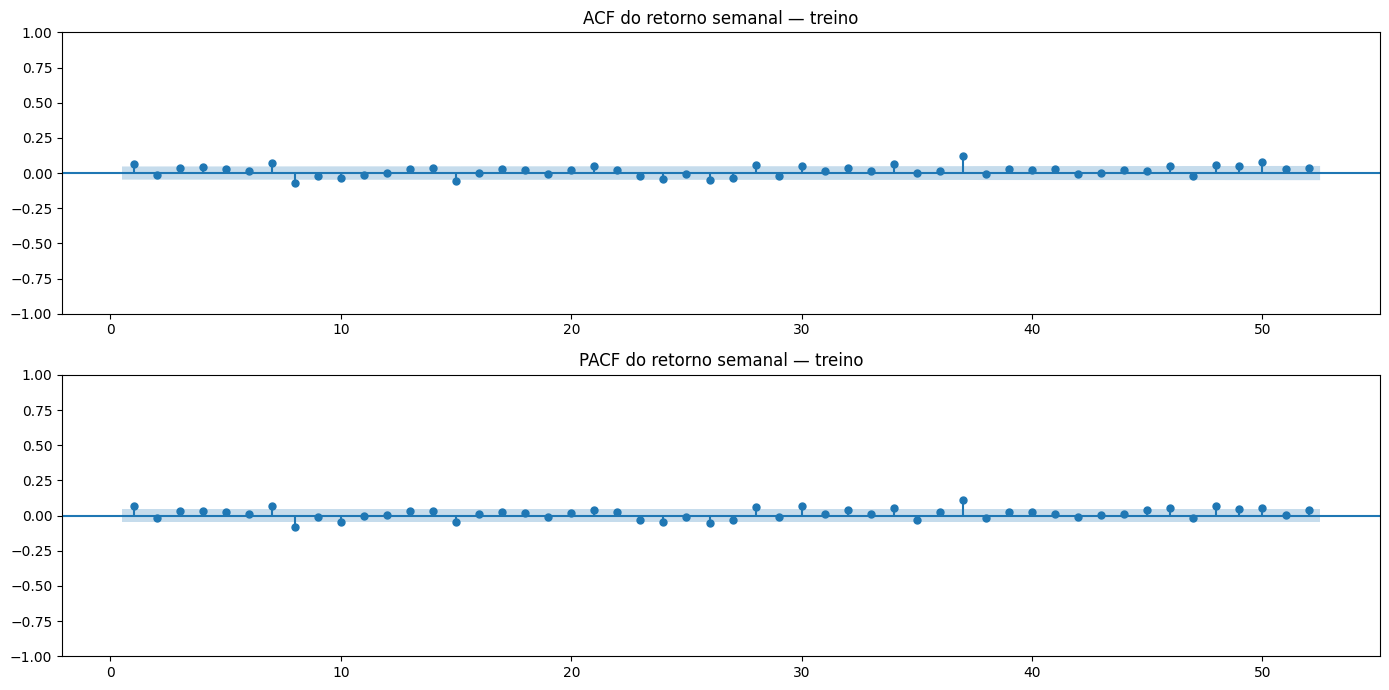

In [7]:
model_df, _ = construir_quadro_ouro(weekly)
if LOG_TARGET not in model_df.columns:
    model_df[LOG_TARGET] = np.log(model_df.target_price_t_plus_1)
assert np.allclose(model_df[LOG_TARGET], np.log(model_df.target_price_t_plus_1))

split_index = int(len(model_df) * TRAIN_RATIO)
first_test_origin = model_df.iloc[split_index].DATE
train_df = model_df.iloc[:split_index].loc[lambda x: x.target_date < first_test_origin].reset_index(drop=True)
test_df = model_df.iloc[split_index:].reset_index(drop=True)
training_df = selecionar_alvos_observados(train_df).reset_index(drop=True)
assert train_df.target_date.max() < test_df.DATE.min()
assert training_df.target_has_new_quote.eq(1).all()
assert len(test_df) == 586, len(test_df)

# Série do Holt-Winters na grade semanal completa (preço ou log do preço, conforme ALVO)
weekly_idx = weekly.set_index('DATE')
y_series = (weekly_idx.price_t if ALVO == 'price' else weekly_idx.log_price_t).astype(float).asfreq(WEEKLY_RULE)
assert y_series.notna().all() and len(y_series) == len(weekly)
to_price = (lambda v: np.asarray(v, dtype=float)) if ALVO == 'price' else (lambda v: np.exp(np.asarray(v, dtype=float)))

# Posições (na grade) das origens e dos alvos de teste
test_origin_pos = y_series.index.get_indexer(pd.DatetimeIndex(test_df.DATE))
assert (test_origin_pos >= 0).all()
assert (y_series.index[test_origin_pos + 1] == pd.DatetimeIndex(test_df.target_date)).all()
assert np.allclose(y_series.iloc[test_origin_pos + 1].to_numpy(), test_df[TARGET].to_numpy())
assert np.allclose(to_price(y_series.iloc[test_origin_pos].to_numpy()), test_df.price_t.to_numpy())

def adf_row(name, series):
    result = adfuller(series.dropna(), autolag='AIC')
    return {'serie': name, 'estatistica': result[0], 'p_valor': result[1], 'lags': result[2]}
display(pd.DataFrame({
    'recorte': ['treino — grade', 'treino — alvos observados', 'teste — grade'],
    'linhas': [len(train_df), len(training_df), len(test_df)],
    'inicio_origem': [train_df.DATE.min(), training_df.DATE.min(), test_df.DATE.min()],
    'fim_origem': [train_df.DATE.max(), training_df.DATE.max(), test_df.DATE.max()],
}))
display(pd.DataFrame([
    adf_row('log do preço semanal — treino', train_df.log_price_t),
    adf_row('retorno log semanal — treino', train_df.log_return_t),
]))
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(train_df.log_return_t, lags=52, zero=False, ax=axes[0])
plot_pacf(train_df.log_return_t, lags=52, zero=False, method='ywm', ax=axes[1])
axes[0].set_title('ACF do retorno semanal — treino')
axes[1].set_title('PACF do retorno semanal — treino')
plt.tight_layout(); plt.show()

## 7. Otimização temporal do Holt-Winters

Mesmo desenho do Random Forest: três dobras expansivas purgadas (`purged_time_series_splits`) sobre
os alvos observados, seleção pelo menor MAE médio e o teste final fora da escolha.
Em cada dobra o modelo é ajustado na série até a primeira origem de validação; depois o estado
(nível, tendência, sazonalidade) é atualizado semana a semana com os parâmetros congelados, e só as
semanas-alvo com cotação nova entram no MAE. O MAE do log-preço é o MAE na escala do alvo (preço, como o RF-preço; ou log-preço, se `ALVO = 'log_price'`).
`alpha`, `beta`, `gamma` e `phi` são estimados no ajuste, com inicialização heurística.
Os candidatos sazonais multiplicativos só entram quando o alvo é o preço em nível; no log-preço a
sazonalidade multiplicativa vira aditiva e não faz sentido.

In [8]:
def ajustar(serie, spec):
    modelo = ExponentialSmoothing(
        serie.astype(float),
        trend=spec['trend'],
        damped_trend=bool(spec['damped_trend']) if spec['trend'] else False,
        seasonal=spec['seasonal'],
        seasonal_periods=spec['seasonal_periods'] if spec['seasonal'] else None,
        initialization_method='heuristic',
    )
    return modelo.fit(optimized=True, remove_bias=False, use_brute=False)


def parametros(resultado):
    params = resultado.params
    alpha = float(params['smoothing_level'])
    beta = params.get('smoothing_trend', np.nan)
    gamma = params.get('smoothing_seasonal', np.nan)
    phi = params.get('damping_trend', np.nan)
    beta = None if beta is None or not np.isfinite(beta) else float(beta)
    gamma = None if gamma is None or not np.isfinite(gamma) else float(gamma)
    phi = 1.0 if phi is None or not np.isfinite(phi) else float(phi)
    return alpha, beta, gamma, phi


def extrair_estado(resultado, spec):
    alpha, beta, gamma, phi = parametros(resultado)
    if not spec['damped_trend']:
        phi = 1.0
    nivel = float(np.asarray(resultado.level)[-1])
    tendencia = None
    if spec['trend'] is not None:
        tendencia = float(np.asarray(resultado.trend)[-1])
        if beta is None:
            beta = 0.0
    sazonal = None
    if spec['seasonal'] is not None:
        periodo = spec['seasonal_periods']
        sazonal = np.asarray(resultado.season, dtype=float)[-periodo:].copy()
        if gamma is None:
            gamma = 0.0
    if not np.isfinite(nivel) or (sazonal is not None and not np.isfinite(sazonal).all()):
        raise RuntimeError('Estado final do Holt-Winters não é finito.')
    return {'level': nivel, 'trend': tendencia, 'season': sazonal,
            'alpha': alpha, 'beta': beta, 'gamma': gamma, 'phi': phi,
            'trend_type': spec['trend'], 'seasonal_type': spec['seasonal']}


def prever_um_passo(estado):
    base = estado['level'] if estado['trend'] is None else estado['level'] + estado['phi'] * estado['trend']
    if estado['seasonal_type'] is None:
        return float(base)
    fator = estado['season'][0]
    return float(base + fator) if estado['seasonal_type'] == 'add' else float(base * fator)


def atualizar_estado(estado, observado):
    alpha, phi = estado['alpha'], estado['phi']
    nivel, tendencia = estado['level'], estado['trend']
    combinado = nivel if tendencia is None else nivel + phi * tendencia
    if estado['seasonal_type'] == 'add':
        fator = estado['season'][0]
        novo_nivel = alpha * (observado - fator) + (1 - alpha) * combinado
    elif estado['seasonal_type'] == 'mul':
        fator = estado['season'][0]
        novo_nivel = alpha * (observado / fator) + (1 - alpha) * combinado
    else:
        novo_nivel = alpha * observado + (1 - alpha) * combinado
    if tendencia is None:
        nova_tendencia = None
    else:
        beta = estado['beta']
        nova_tendencia = beta * (novo_nivel - nivel) + (1 - beta) * phi * tendencia
    if estado['seasonal_type'] is None:
        nova_sazonal = None
    else:
        # Mesma atualização sazonal do statsmodels: usa o nível previsto anterior
        gamma = estado['gamma']
        if estado['seasonal_type'] == 'add':
            novo_fator = gamma * (observado - combinado) + (1 - gamma) * fator
        else:
            novo_fator = gamma * (observado / combinado) + (1 - gamma) * fator
        nova_sazonal = np.concatenate([estado['season'][1:], [novo_fator]])
    return {**estado, 'level': float(novo_nivel),
            'trend': None if nova_tendencia is None else float(nova_tendencia),
            'season': nova_sazonal}


def caminho_um_passo(estado, valores, inicio, fim_inclusivo, posicoes_avaliadas):
    """Percorre a grade atualizando o estado em TODAS as semanas; guarda só as posições pedidas."""
    previsoes = {}
    for posicao in range(inicio, fim_inclusivo + 1):
        previsao = prever_um_passo(estado)
        if posicao in posicoes_avaliadas:
            previsoes[posicao] = previsao
        estado = atualizar_estado(estado, float(valores[posicao]))
    return previsoes


def spec_publica(spec):
    return {'nome': spec['nome'], 'trend': spec['trend'] or 'nenhuma',
            'seasonal': spec['seasonal'] or 'nenhuma',
            'seasonal_periods': spec['seasonal_periods'],
            'damped_trend': bool(spec['damped_trend']) if spec['trend'] else False}

In [9]:
candidates = [
    {'nome': 'suavização simples', 'trend': None, 'seasonal': None, 'seasonal_periods': None, 'damped_trend': False},
    {'nome': 'Holt aditivo', 'trend': 'add', 'seasonal': None, 'seasonal_periods': None, 'damped_trend': False},
    {'nome': 'Holt aditivo amortecido', 'trend': 'add', 'seasonal': None, 'seasonal_periods': None, 'damped_trend': True},
    {'nome': 'sazonalidade aditiva anual', 'trend': None, 'seasonal': 'add', 'seasonal_periods': 52, 'damped_trend': False},
    {'nome': 'Holt-Winters aditivo anual', 'trend': 'add', 'seasonal': 'add', 'seasonal_periods': 52, 'damped_trend': False},
    {'nome': 'Holt-Winters aditivo amortecido anual', 'trend': 'add', 'seasonal': 'add', 'seasonal_periods': 52, 'damped_trend': True},
]
if ALVO == 'price':
    candidates += [
        {'nome': 'Holt-Winters multiplicativo anual', 'trend': 'add', 'seasonal': 'mul', 'seasonal_periods': 52, 'damped_trend': False},
        {'nome': 'Holt-Winters multiplicativo amortecido anual', 'trend': 'add', 'seasonal': 'mul', 'seasonal_periods': 52, 'damped_trend': True},
    ]

cv_splits = purged_time_series_splits(training_df.DATE, training_df.target_date, n_splits=3)
y_values = y_series.to_numpy()
training_origin_pos = y_series.index.get_indexer(pd.DatetimeIndex(training_df.DATE))
assert (training_origin_pos >= 0).all()

search_rows = []
search_start = time.perf_counter()
for candidate_id, spec in enumerate(candidates, start=1):
    fold_maes, fold_seconds = [], []
    erro = ''
    for fold, (fit_idx, validation_idx) in enumerate(cv_splits, start=1):
        fold_start = time.perf_counter()
        try:
            origens_val = training_origin_pos[np.asarray(validation_idx)]
            alvos_val = origens_val + 1                       # só semanas-alvo com cotação nova
            fit_end = int(origens_val.min())
            resultado = ajustar(y_series.iloc[: fit_end + 1], spec)
            estado = extrair_estado(resultado, spec)
            previsoes = caminho_um_passo(estado, y_values, fit_end + 1, int(alvos_val.max()), set(int(p) for p in alvos_val))
            previsto = np.array([previsoes[int(p)] for p in alvos_val])
            fold_maes.append(float(np.mean(np.abs(y_values[alvos_val] - previsto))))
        except Exception as exc:
            erro = str(exc).split('\n')[0][:200]
            fold_maes.append(np.nan)
        fold_seconds.append(time.perf_counter() - fold_start)
    search_rows.append({
        'candidate_id': candidate_id, **spec_publica(spec),
        'mean_validation_mae': np.mean(fold_maes),
        'std_validation_mae': np.std(fold_maes, ddof=1),
        'dobras_ok': int(np.isfinite(fold_maes).sum()),
        'fit_seconds': np.sum(fold_seconds), 'erro': erro,
    })
search_seconds = time.perf_counter() - search_start
search_results = pd.DataFrame(search_rows).sort_values(
    ['mean_validation_mae', 'std_validation_mae', 'candidate_id'], na_position='last'
).reset_index(drop=True)
validos = search_results.loc[search_results.dobras_ok.eq(len(cv_splits))]
assert len(validos), 'Nenhum candidato ajustou em todas as dobras.'
best_spec = next(spec for spec in candidates if spec['nome'] == validos.iloc[0]['nome'])
display(search_results)
print('Melhor especificação:', best_spec['nome'])
print(f'Tempo de busca: {search_seconds:.2f} s')

,candidate_id,nome,trend,seasonal,seasonal_periods,damped_trend,mean_validation_mae,std_validation_mae,dobras_ok,fit_seconds,erro
0,2,Holt aditivo,add,nenhuma,NaN,False,6.896391,4.299945,3,0.078710,
1,1,suavização simples,nenhuma,nenhuma,NaN,False,6.898374,4.306421,3,0.049489,
2,5,Holt-Winters aditivo anual,add,add,52.0,False,6.925825,4.303271,3,0.121298,
3,4,sazonalidade aditiva anual,nenhuma,add,52.0,False,6.926449,4.305141,3,0.076783,
4,3,Holt aditivo amortecido,add,nenhuma,NaN,True,6.977449,4.441995,3,0.073025,
5,6,Holt-Winters aditivo amortecido anual,add,add,52.0,True,7.007137,4.445059,3,0.160476,
6,7,Holt-Winters multiplicativo anual,add,mul,52.0,False,7.303626,4.292934,3,0.145468,
7,8,Holt-Winters multiplicativo amortecido anual,add,mul,52.0,True,7.383871,4.429696,3,0.278402,


Melhor especificação: Holt aditivo
Tempo de busca: 0.99 s


## 8. Walk-forward final e parâmetros estimados

A especificação escolhida fica fixa. Em cada bloco de `REFIT_EVERY` origens o modelo é reajustado
na série do modelo até a origem (só informação já revelada); dentro do bloco o estado é
atualizado semana a semana. Todas as 586 origens recebem uma previsão fora da amostra, mas as
métricas principais usam só as semanas-alvo com cotação nova. Não há features: no lugar da
importância, a tabela mostra a estabilidade dos parâmetros ao longo dos reajustes.

,DATE,target_date,price_t,target_price_t_plus_1,target_log_price_t_plus_1,y_true_return,target_has_new_quote,has_source_observation_t,pred_hw_escala_modelo,model_refit_origin,state_data_cutoff,price_pred_hw,y_pred_return_hw,y_pred_return_zero,price_pred_persistence,residual_log_price_hw,residual_return_hw,residual_price_hw,absolute_error_price_hw
0,2003-01-17,2003-01-24,358.20,364.10,5.897429,0.016337,1,1,358.278564,2003-01-17,2003-01-17,358.278564,0.000219,0.0,358.20,0.016118,0.016118,5.821436,5.821436
1,2003-01-24,2003-01-31,364.10,370.35,5.914449,0.017020,1,1,364.177517,2003-01-24,2003-01-24,364.177517,0.000213,0.0,364.10,0.016807,0.016807,6.172483,6.172483
2,2003-01-31,2003-02-07,370.35,370.55,5.914988,0.000540,1,1,370.427921,2003-01-31,2003-01-31,370.427921,0.000210,0.0,370.35,0.000330,0.000330,0.122079,0.122079
3,2003-02-07,2003-02-14,370.55,356.25,5.875633,-0.039356,1,1,370.639762,2003-02-07,2003-02-07,370.639762,0.000242,0.0,370.55,-0.039598,-0.039598,-14.389762,14.389762
4,2003-02-14,2003-02-21,356.25,354.00,5.869297,-0.006336,1,1,356.368254,2003-02-14,2003-02-14,356.368254,0.000332,0.0,356.25,-0.006668,-0.006668,-2.368254,2.368254


,mean,std,min,max
alpha,0.981801,0.019609,0.922995,1.000000
beta,0.001003,0.001488,0.000000,0.007013
gamma,NaN,NaN,NaN,NaN
phi,1.000000,0.000000,1.000000,1.000000


Especificação: Holt aditivo | origens: 586 | com cotação nova: 523


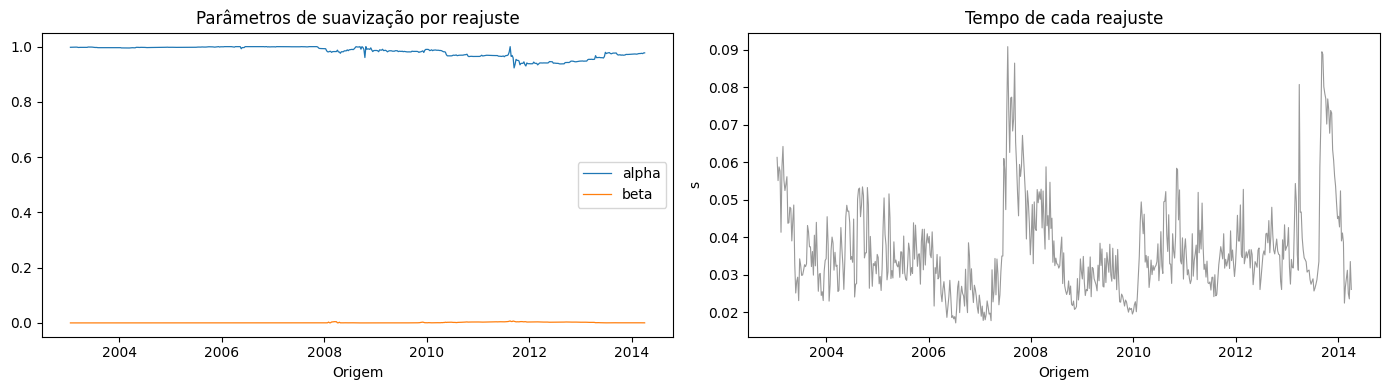

In [10]:
prediction_values, prediction_refits, state_cutoffs = [], [], []
fit_rows = []
evaluation_start = time.perf_counter()
n_test = len(test_df)
for block_start in range(0, n_test, REFIT_EVERY):
    block_end = min(block_start + REFIT_EVERY, n_test)
    origin_pos = int(test_origin_pos[block_start])
    current_origin = y_series.index[origin_pos]
    fit_start = time.perf_counter()
    resultado = ajustar(y_series.iloc[: origin_pos + 1], best_spec)
    estado = extrair_estado(resultado, best_spec)
    alpha, beta, gamma, phi = parametros(resultado)
    fit_seconds = time.perf_counter() - fit_start
    for k in range(block_start, block_end):
        prediction_values.append(prever_um_passo(estado))
        prediction_refits.append(current_origin)
        state_cutoffs.append(y_series.index[int(test_origin_pos[k])])     # último dado visto pelo estado
        # o valor-alvo de k só é revelado na origem k+1; aí o estado o incorpora
        estado = atualizar_estado(estado, float(y_values[int(test_origin_pos[k]) + 1]))
    fit_rows.append({
        'origem_refit': current_origin, 'linhas_historico': origin_pos + 1,
        'inicio_bloco': block_start, 'fim_bloco_exclusivo': block_end,
        'alpha': alpha, 'beta': beta, 'gamma': gamma,
        'phi': phi if best_spec['damped_trend'] else 1.0,
        'fit_seconds': fit_seconds,
    })
evaluation_seconds = time.perf_counter() - evaluation_start

predictions = test_df[[
    'DATE', 'target_date', 'price_t', 'target_price_t_plus_1', LOG_TARGET,
    'target_log_return_t_plus_1', 'target_has_new_quote', 'has_source_observation_t',
]].copy()
predictions = predictions.rename(columns={'target_log_return_t_plus_1': 'y_true_return'})
predictions['pred_hw_escala_modelo'] = np.asarray(prediction_values)
predictions['model_refit_origin'] = prediction_refits
predictions['state_data_cutoff'] = state_cutoffs
assert (predictions.state_data_cutoff <= predictions.DATE).all()
predictions['price_pred_hw'] = to_price(predictions.pred_hw_escala_modelo)
assert predictions.price_pred_hw.gt(0).all(), 'previsão de preço não positiva'
predictions['y_pred_return_hw'] = np.log(predictions.price_pred_hw / predictions.price_t)
predictions['y_pred_return_zero'] = 0.
predictions['price_pred_persistence'] = predictions.price_t
predictions['residual_log_price_hw'] = predictions[LOG_TARGET] - np.log(predictions.price_pred_hw)
predictions['residual_return_hw'] = predictions.y_true_return - predictions.y_pred_return_hw
assert np.allclose(predictions.residual_log_price_hw, predictions.residual_return_hw)
predictions['residual_price_hw'] = predictions.target_price_t_plus_1 - predictions.price_pred_hw
predictions['absolute_error_price_hw'] = predictions.residual_price_hw.abs()
observed_predictions = predictions.loc[predictions.target_has_new_quote.eq(1)].copy()

fit_log = pd.DataFrame(fit_rows)
param_summary = fit_log[['alpha', 'beta', 'gamma', 'phi']].agg(['mean', 'std', 'min', 'max']).T
display(predictions.head())
display(param_summary)
print(f'Especificação: {best_spec["nome"]} | origens: {len(predictions)} | '
      f'com cotação nova: {len(observed_predictions)}')
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(fit_log.origem_refit, fit_log.alpha, label='alpha', lw=.9)
if fit_log.beta.notna().any(): axes[0].plot(fit_log.origem_refit, fit_log.beta, label='beta', lw=.9)
if fit_log.gamma.notna().any(): axes[0].plot(fit_log.origem_refit, fit_log.gamma, label='gamma', lw=.9)
axes[0].set(title='Parâmetros de suavização por reajuste', xlabel='Origem'); axes[0].legend()
axes[1].plot(fit_log.origem_refit, fit_log.fit_seconds, color='#999999', lw=.8)
axes[1].set(title='Tempo de cada reajuste', xlabel='Origem', ylabel='s')
plt.tight_layout(); plt.show()

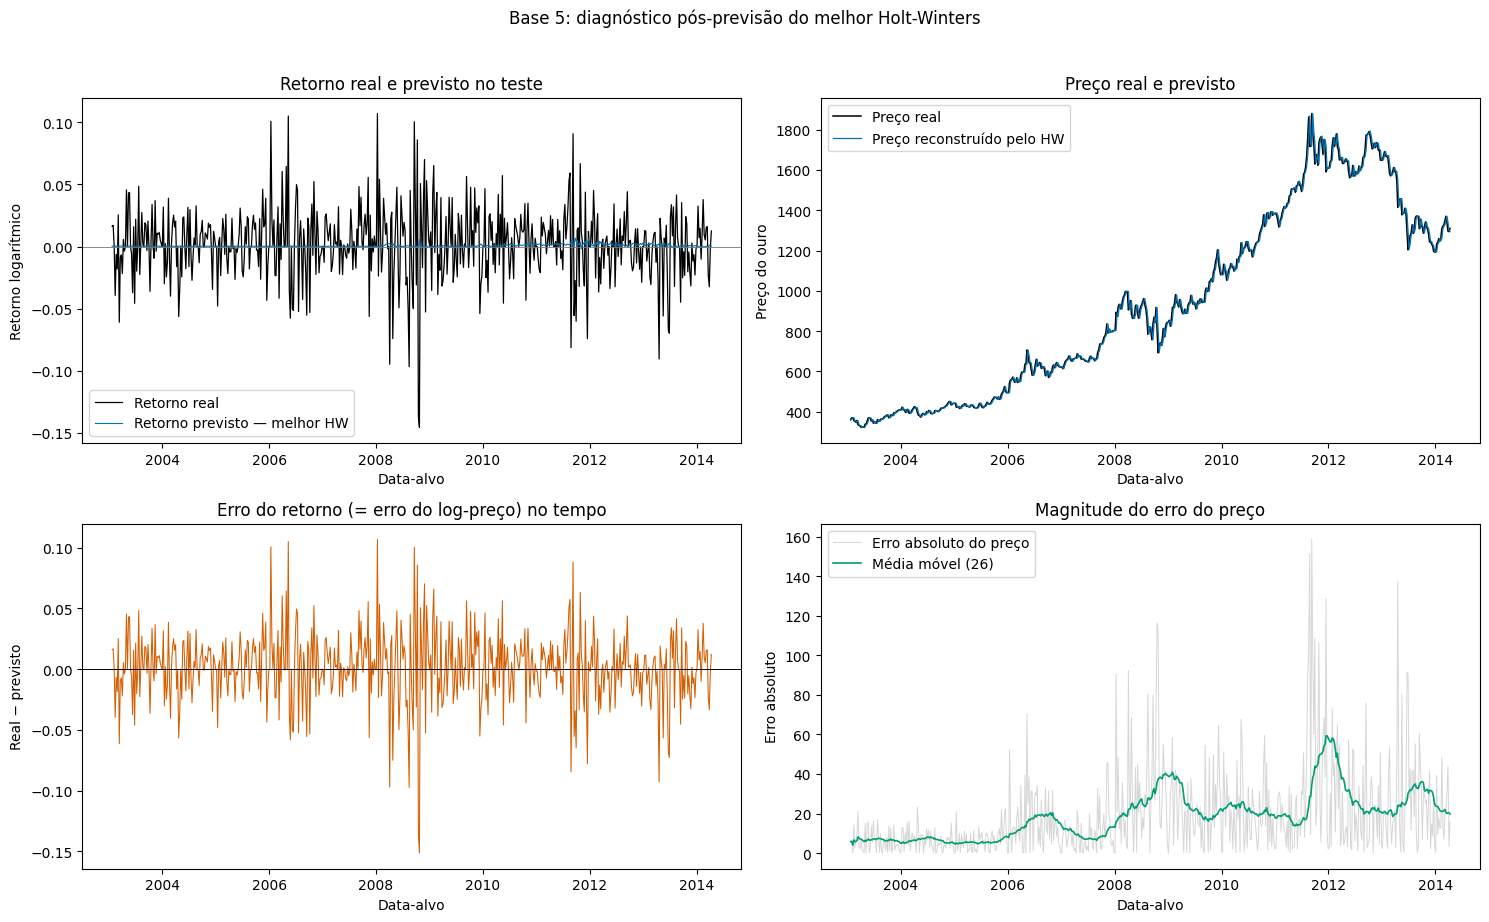

In [11]:
# Diagnóstico visual fora da amostra do melhor Holt-Winters no log-preço
diagnostic_window = min(26, max(5, len(predictions) // 10))
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(predictions.target_date, predictions.y_true_return, label='Retorno real', color='black', lw=.9)
axes[0, 0].plot(predictions.target_date, predictions.y_pred_return_hw, label='Retorno previsto — melhor HW', color='#0072b2', lw=.8)
axes[0, 0].axhline(0, color='#777777', lw=.6)
axes[0, 0].set(title='Retorno real e previsto no teste', xlabel='Data-alvo', ylabel='Retorno logarítmico')
axes[0, 0].legend()

axes[0, 1].plot(predictions.target_date, predictions.target_price_t_plus_1, label='Preço real', color='black', lw=1.1)
axes[0, 1].plot(predictions.target_date, predictions.price_pred_hw, label='Preço reconstruído pelo HW', color='#0072b2', lw=.9)
axes[0, 1].set(title='Preço real e previsto', xlabel='Data-alvo', ylabel='Preço do ouro')
axes[0, 1].legend()

axes[1, 0].plot(predictions.target_date, predictions.residual_return_hw, color='#d55e00', lw=.75)
axes[1, 0].axhline(0, color='black', lw=.7)
axes[1, 0].set(title='Erro do retorno (= erro do log-preço) no tempo', xlabel='Data-alvo', ylabel='Real − previsto')

axes[1, 1].plot(predictions.target_date, predictions.absolute_error_price_hw, color='#999999', alpha=.4, lw=.7, label='Erro absoluto do preço')
axes[1, 1].plot(predictions.target_date, predictions.absolute_error_price_hw.rolling(diagnostic_window, min_periods=1).mean(), color='#009e73', lw=1.2, label=f'Média móvel ({diagnostic_window})')
axes[1, 1].set(title='Magnitude do erro do preço', xlabel='Data-alvo', ylabel='Erro absoluto')
axes[1, 1].legend()

fig.suptitle('Base 5: diagnóstico pós-previsão do melhor Holt-Winters', y=1.02)
plt.tight_layout(); plt.show()

## 9. MAE e demais métricas

A avaliação principal usa semanas-alvo com cotação nova. A grade completa é apresentada somente como
sensibilidade (semanas sem cotação têm retorno real zero por construção); o recorte com cotação na
origem e no alvo é uma robustez adicional. O MAE principal é `MAE_preco` (alvo oficial); `MAE_retorno`
permite comparar com RF-retorno e XGBoost, e coincide com `MAE_log_preco`.

In [12]:
def metric_row(name, return_prediction, price_prediction, subset=None):
    mask = pd.Series(True, index=predictions.index) if subset is None else subset
    actual_return = predictions.loc[mask, 'y_true_return']
    predicted_return = np.asarray(return_prediction)[mask.to_numpy()]
    actual_price = predictions.loc[mask, 'target_price_t_plus_1']
    predicted_price = np.asarray(price_prediction)[mask.to_numpy()]
    return {
        'modelo': name, 'observacoes': int(mask.sum()),
        'MAE_log_preco': mean_absolute_error(predictions.loc[mask, LOG_TARGET],
                                             predictions.loc[mask, 'price_t'].pipe(np.log) + predicted_return),
        'MAE_retorno': mean_absolute_error(actual_return, predicted_return),
        'RMSE_retorno': mean_squared_error(actual_return, predicted_return) ** .5,
        'MedAE_retorno': median_absolute_error(actual_return, predicted_return),
        'R2_retorno': r2_score(actual_return, predicted_return),
        'vies_retorno': np.mean(actual_return - predicted_return),
        'acuracia_direcional': np.mean(np.sign(actual_return) == np.sign(predicted_return)),
        'MAE_preco': mean_absolute_error(actual_price, predicted_price),
    }

new_quote = predictions.target_has_new_quote.eq(1)
origin_and_target_quote = predictions.has_source_observation_t.eq(1) & new_quote
metrics = pd.DataFrame([
    metric_row('Holt-Winters — nova cotação', predictions.y_pred_return_hw, predictions.price_pred_hw, new_quote),
    metric_row('Persistência — nova cotação', predictions.y_pred_return_zero, predictions.price_pred_persistence, new_quote),
    metric_row('Holt-Winters — origem e alvo com cotação', predictions.y_pred_return_hw, predictions.price_pred_hw, origin_and_target_quote),
    metric_row('Persistência — origem e alvo com cotação', predictions.y_pred_return_zero, predictions.price_pred_persistence, origin_and_target_quote),
    metric_row('Holt-Winters — todas (sensibilidade)', predictions.y_pred_return_hw, predictions.price_pred_hw),
    metric_row('Persistência — todas (sensibilidade)', predictions.y_pred_return_zero, predictions.price_pred_persistence),
])
metrics['skill_mae_preco_vs_persistencia'] = np.nan
metrics['skill_mae_retorno_vs_persistencia'] = np.nan
for suffix in ('nova cotação', 'origem e alvo com cotação', 'todas (sensibilidade)'):
    base = metrics.loc[metrics.modelo.eq(f'Persistência — {suffix}')].iloc[0]
    scope = metrics.modelo.str.endswith(suffix)
    metrics.loc[scope, 'skill_mae_preco_vs_persistencia'] = 1 - metrics.loc[scope, 'MAE_preco'] / base.MAE_preco
    metrics.loc[scope, 'skill_mae_retorno_vs_persistencia'] = 1 - metrics.loc[scope, 'MAE_retorno'] / base.MAE_retorno
assert np.allclose(metrics.MAE_log_preco, metrics.MAE_retorno)
display(metrics)

,modelo,observacoes,MAE_log_preco,MAE_retorno,RMSE_retorno,MedAE_retorno,R2_retorno,vies_retorno,acuracia_direcional,MAE_preco,skill_mae_preco_vs_persistencia,skill_mae_retorno_vs_persistencia
0,Holt-Winters — nova cotação,523,0.022485,0.022485,0.030189,0.018226,-0.012931,0.001838,0.562141,21.194296,0.001912,0.001633
1,Persistência — nova cotação,523,0.022522,0.022522,0.030098,0.018257,-0.006830,0.002479,0.001912,21.234895,0.000000,0.000000
2,Holt-Winters — origem e alvo com cotação,469,0.021169,0.021169,0.028310,0.017382,-0.011555,0.000804,0.556503,20.164933,0.000322,0.000774
3,Persistência — origem e alvo com cotação,469,0.021185,0.021185,0.028185,0.017469,-0.002649,0.001449,0.002132,20.171429,0.000000,0.000000
4,Holt-Winters — todas (sensibilidade),586,0.020141,0.020141,0.028523,0.016262,-0.012360,0.001570,0.501706,19.013652,-0.003255,-0.002003
5,Persistência — todas (sensibilidade),586,0.020101,0.020101,0.028434,0.016044,-0.006091,0.002212,0.109215,18.951962,0.000000,0.000000


## 10. Registro de parâmetros, versões e tempo

O registro reúne hash, configuração, parâmetros, versões, tempos e cada reajuste do teste
para reprodução completa.

In [13]:
experiment_record = pd.DataFrame([{
    'base': 'Base 5 — ouro semanal', 'arquivo': str(DATA_PATH.relative_to(ROOT)),
    'sha256': file_hash, 'frequencia': WEEKLY_RULE,
    'alvo': TARGET, 'serie_ajustada_hw': 'price_t' if ALVO == 'price' else 'log_price_t', 'horizonte_provisorio': '1 semana',
    'split_treino': TRAIN_RATIO, 'random_state': RANDOM_STATE,
    'linhas_treino_grade': len(train_df), 'linhas_treino_alvo_observado': len(training_df),
    'linhas_teste': len(test_df), 'linhas_teste_alvo_observado': int(test_df.target_has_new_quote.sum()),
    'linhas_teste_origem_e_alvo_observados': int((test_df.has_source_observation_t.eq(1) & test_df.target_has_new_quote.eq(1)).sum()),
    'origem_teste_inicial': test_df.DATE.min(), 'origem_teste_final': test_df.DATE.max(),
    'numero_features': 0, 'features': json.dumps([]),
    'candidatos_tuning': len(candidates), 'dobras_validacao': len(cv_splits),
    'melhor_especificacao': json.dumps(spec_publica(best_spec), ensure_ascii=False),
    'parametros_medios_walk_forward': json.dumps(
        {k: (None if pd.isna(v) else float(v)) for k, v in fit_log[['alpha', 'beta', 'gamma', 'phi']].mean().items()}),
    'tempo_busca_s': search_seconds, 'tempo_walk_forward_s': evaluation_seconds,
    'refit_every': REFIT_EVERY, 'numero_refits_teste': len(fit_log), 'python': platform.python_version(),
    'pandas': pd.__version__, 'numpy': np.__version__, 'statsmodels': statsmodels.__version__,
}])
display(experiment_record.T)
display(fit_log)

,0
base,Base 5 — ouro semanal
arquivo,data\base_05\raw.csv
sha256,c852759b32f534918f76f9c3a31342228bf0bbc8a61fc5...
frequencia,W-FRI
alvo,target_price_t_plus_1
serie_ajustada_hw,price_t
horizonte_provisorio,1 semana
split_treino,0.75
random_state,42
linhas_treino_grade,1757


,origem_refit,linhas_historico,inicio_bloco,fim_bloco_exclusivo,alpha,beta,gamma,phi,fit_seconds
0,2003-01-17,1812,0,1,0.997704,0.000000,None,1.0,0.061269
1,2003-01-24,1813,1,2,0.997855,0.000000,None,1.0,0.055082
2,2003-01-31,1814,2,3,0.998043,0.000000,None,1.0,0.058743
3,2003-02-07,1815,3,4,0.998047,0.000000,None,1.0,0.057643
4,2003-02-14,1816,4,5,0.998037,0.000000,None,1.0,0.041317
...,...,...,...,...,...,...,...,...,...
581,2014-03-07,2393,581,582,0.975198,0.000400,None,1.0,0.031200
582,2014-03-14,2394,582,583,0.975912,0.000443,None,1.0,0.024942
583,2014-03-21,2395,583,584,0.974783,0.000380,None,1.0,0.023565
584,2014-03-28,2396,584,585,0.977237,0.000293,None,1.0,0.033524


## 11. Resíduos individuais

Os diagnósticos residuais usam somente semanas-alvo com cotação efetivamente observada.
Com `ALVO = 'price'` o resíduo é o do preço (como no RF-preço); com `'log_price'`, o do log-preço,
que é o do retorno.

In [14]:
RESIDUAL_COL = 'residual_price_hw' if ALVO == 'price' else 'residual_return_hw'
RESIDUAL_LABEL = 'preço' if ALVO == 'price' else 'retorno'
residuals = observed_predictions[RESIDUAL_COL]

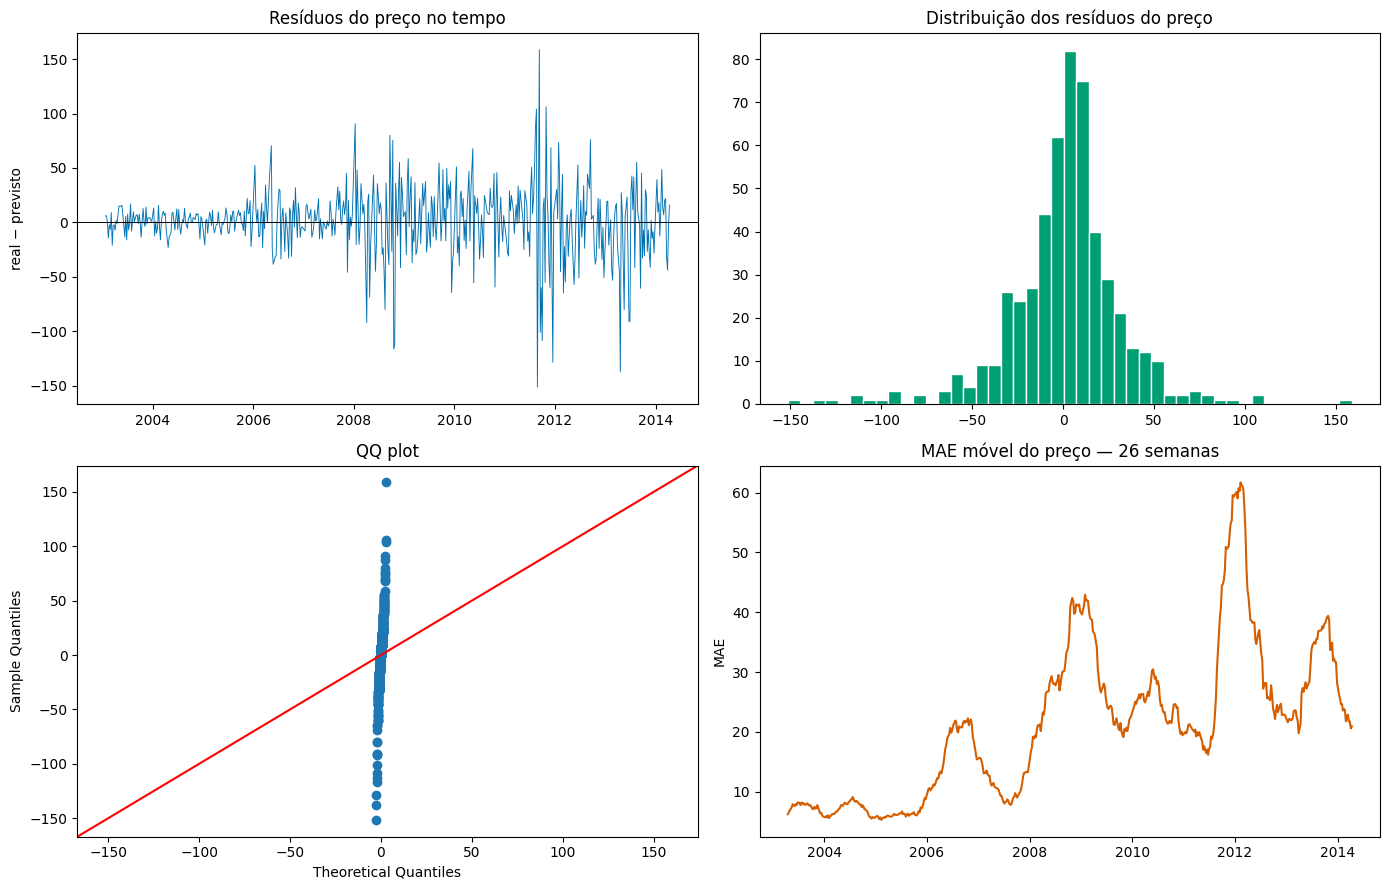

,DATE,target_date,price_t,target_price_t_plus_1,target_log_price_t_plus_1,y_true_return,target_has_new_quote,has_source_observation_t,pred_hw_escala_modelo,model_refit_origin,state_data_cutoff,price_pred_hw,y_pred_return_hw,y_pred_return_zero,price_pred_persistence,residual_log_price_hw,residual_return_hw,residual_price_hw,absolute_error_price_hw
0,2003-01-17,2003-01-24,358.20,364.10,5.897429,0.016337,1,1,358.278564,2003-01-17,2003-01-17,358.278564,0.000219,0.0,358.20,0.016118,0.016118,5.821436,5.821436
1,2003-01-24,2003-01-31,364.10,370.35,5.914449,0.017020,1,1,364.177517,2003-01-24,2003-01-24,364.177517,0.000213,0.0,364.10,0.016807,0.016807,6.172483,6.172483
2,2003-01-31,2003-02-07,370.35,370.55,5.914988,0.000540,1,1,370.427921,2003-01-31,2003-01-31,370.427921,0.000210,0.0,370.35,0.000330,0.000330,0.122079,0.122079
3,2003-02-07,2003-02-14,370.55,356.25,5.875633,-0.039356,1,1,370.639762,2003-02-07,2003-02-07,370.639762,0.000242,0.0,370.55,-0.039598,-0.039598,-14.389762,14.389762
4,2003-02-14,2003-02-21,356.25,354.00,5.869297,-0.006336,1,1,356.368254,2003-02-14,2003-02-14,356.368254,0.000332,0.0,356.25,-0.006668,-0.006668,-2.368254,2.368254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581,2014-03-07,2014-03-14,1348.25,1370.00,7.222566,0.016003,1,1,1348.186178,2014-03-07,2014-03-07,1348.186178,-0.000047,0.0,1348.25,0.016051,0.016051,21.813822,21.813822
582,2014-03-14,2014-03-21,1370.00,1338.50,7.199305,-0.023261,1,1,1369.952639,2014-03-14,2014-03-14,1369.952639,-0.000035,0.0,1370.00,-0.023227,-0.023227,-31.452639,31.452639
583,2014-03-21,2014-03-28,1338.50,1295.75,7.166845,-0.032460,1,1,1339.711857,2014-03-21,2014-03-21,1339.711857,0.000905,0.0,1338.50,-0.033365,-0.033365,-43.961857,43.961857
584,2014-03-28,2014-04-04,1295.75,1293.50,7.165107,-0.001738,1,1,1297.091563,2014-03-28,2014-03-28,1297.091563,0.001035,0.0,1295.75,-0.002773,-0.002773,-3.591563,3.591563


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(observed_predictions.target_date, residuals, lw=.65, color='#0072b2')
axes[0, 0].axhline(0, color='black', lw=.7)
axes[0, 0].set(title=f'Resíduos do {RESIDUAL_LABEL} no tempo', ylabel='real − previsto')
axes[0, 1].hist(residuals, bins=45, edgecolor='white', color='#009e73')
axes[0, 1].set(title=f'Distribuição dos resíduos do {RESIDUAL_LABEL}')
sm.qqplot(residuals, line='45', ax=axes[1, 0]); axes[1, 0].set_title('QQ plot')
axes[1, 1].plot(observed_predictions.target_date, observed_predictions.absolute_error_price_hw.rolling(26, min_periods=13).mean(), color='#d55e00')
axes[1, 1].set(title='MAE móvel do preço — 26 semanas', ylabel='MAE')
plt.tight_layout(); plt.show()
display(predictions)

## 12. ACF dos resíduos e Ljung–Box

A ACF e o Ljung–Box verificam se o Holt-Winters deixou dependência temporal nos erros.
Rejeição a 5% indica que o resíduo não se comporta como ruído branco.

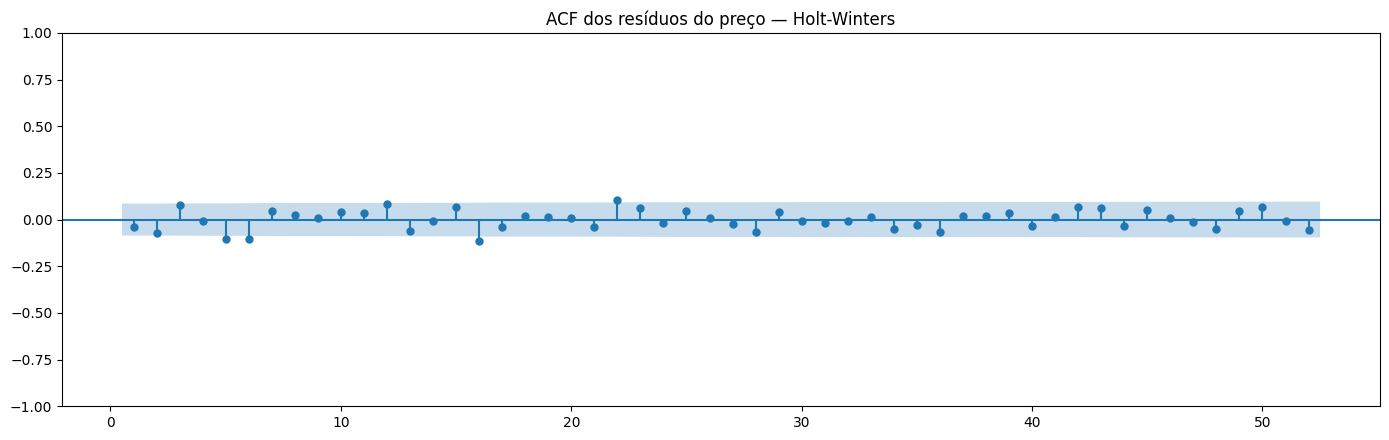

,lb_stat,lb_pvalue,rejeita_ruido_branco_5pct
1,0.816381,0.366240,False
4,6.660345,0.154964,False
13,26.749734,0.013460,True
26,48.398373,0.004857,True


In [16]:
fig, ax = plt.subplots(figsize=(14, 4.5))
plot_acf(residuals, lags=52, zero=False, ax=ax)
ax.set_title(f'ACF dos resíduos do {RESIDUAL_LABEL} — Holt-Winters')
plt.tight_layout(); plt.show()
ljung_box = acorr_ljungbox(residuals, lags=[1, 4, 13, 26], return_df=True)
ljung_box['rejeita_ruido_branco_5pct'] = ljung_box.lb_pvalue < .05
display(ljung_box)

## 13. Previsões e métricas do preço do ouro

Esta seção expõe a saída final do modelo na unidade de interesse: o preço do ouro da semana seguinte
(com `ALVO = 'log_price'`, a previsão em log é convertida por `exp`). Todas as linhas abaixo são previsões
fora da amostra do walk-forward.

Métricas de erro do preço — fora da amostra e com cotação nova:


,modelo,observacoes,MAE_preco,RMSE_preco,MedAE_preco,MAPE_preco_pct,R2_preco,vies_preco_real_menos_previsto,skill_MAE_vs_persistencia
0,Holt-Winters,523,21.194296,31.172451,13.685302,2.24967,0.995366,0.969482,0.001912
1,Persistência,523,21.234895,31.029890,14.000000,2.25174,0.995409,1.819407,0.000000


Previsão de preço mais recente disponível no teste:


,585
data_origem,2014-04-04 00:00:00
data_prevista,2014-04-11 00:00:00
preco_na_origem,1293.5
preco_real,1309.75
preco_previsto_hw,1293.918619
preco_previsto_persistencia,1293.5
tem_cotacao_nova,1
erro_hw,15.831381
erro_absoluto_hw,15.831381
erro_percentual_absoluto_hw_pct,1.208733


Últimas 20 previsões de preço:


,data_origem,data_prevista,preco_na_origem,preco_real,preco_previsto_hw,preco_previsto_persistencia,tem_cotacao_nova,erro_hw,erro_absoluto_hw,erro_percentual_absoluto_hw_pct
566,2013-11-22,2013-11-29,1241.75,1245.25,1243.191684,1241.75,1,2.058316,2.058316,0.165293
567,2013-11-29,2013-12-06,1245.25,1230.75,1245.481347,1245.25,1,-14.731347,14.731347,1.196941
568,2013-12-06,2013-12-13,1230.75,1222.75,1231.434941,1230.75,1,-8.684941,8.684941,0.710279
569,2013-12-13,2013-12-20,1222.75,1195.00,1223.250051,1222.75,1,-28.250051,28.250051,2.364021
570,2013-12-20,2013-12-27,1195.00,1192.75,1195.996656,1195.00,1,-3.246656,3.246656,0.272199
571,2013-12-27,2014-01-03,1192.75,1192.75,1193.054365,1192.75,0,-0.304365,0.304365,0.025518
572,2014-01-03,2014-01-10,1192.75,1232.25,1192.973696,1192.75,1,39.276304,39.276304,3.187365
573,2014-01-10,2014-01-17,1232.25,1241.00,1231.436809,1232.25,1,9.563191,9.563191,0.770604
574,2014-01-17,2014-01-24,1241.00,1259.25,1241.020805,1241.00,1,18.229195,18.229195,1.447623
575,2014-01-24,2014-01-31,1259.25,1246.50,1259.068181,1259.25,1,-12.568181,12.568181,1.008278


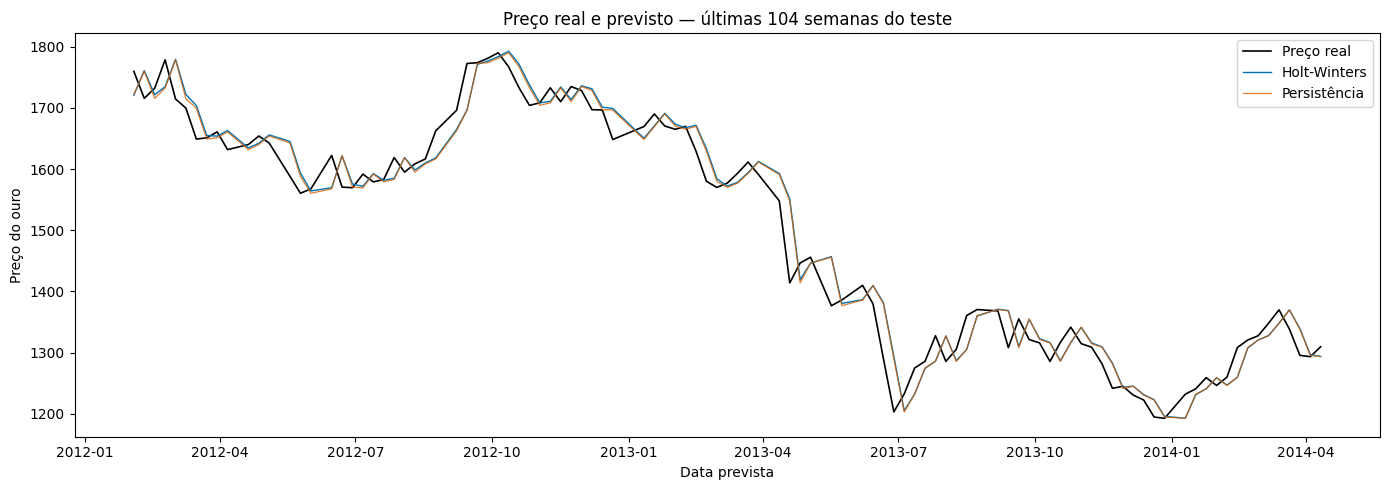

In [17]:
price_forecasts = predictions[[
    'DATE', 'target_date', 'price_t', 'target_price_t_plus_1',
    'price_pred_hw', 'price_pred_persistence', 'target_has_new_quote',
]].copy()
price_forecasts = price_forecasts.rename(columns={
    'DATE': 'data_origem',
    'target_date': 'data_prevista',
    'price_t': 'preco_na_origem',
    'target_price_t_plus_1': 'preco_real',
    'price_pred_hw': 'preco_previsto_hw',
    'price_pred_persistence': 'preco_previsto_persistencia',
    'target_has_new_quote': 'tem_cotacao_nova',
})
price_forecasts['erro_hw'] = price_forecasts.preco_real - price_forecasts.preco_previsto_hw
price_forecasts['erro_absoluto_hw'] = price_forecasts.erro_hw.abs()
price_forecasts['erro_percentual_absoluto_hw_pct'] = (
    100 * price_forecasts.erro_absoluto_hw / price_forecasts.preco_real
)


def price_metric_row(name, values):
    mask = price_forecasts.tem_cotacao_nova.eq(1)
    actual = price_forecasts.loc[mask, 'preco_real']
    predicted = np.asarray(values)[mask.to_numpy()]
    return {
        'modelo': name,
        'observacoes': len(actual),
        'MAE_preco': mean_absolute_error(actual, predicted),
        'RMSE_preco': mean_squared_error(actual, predicted) ** .5,
        'MedAE_preco': median_absolute_error(actual, predicted),
        'MAPE_preco_pct': np.mean(np.abs((actual - predicted) / actual)) * 100,
        'R2_preco': r2_score(actual, predicted),
        'vies_preco_real_menos_previsto': np.mean(actual - predicted),
    }


price_error_metrics = pd.DataFrame([
    price_metric_row('Holt-Winters', price_forecasts.preco_previsto_hw),
    price_metric_row('Persistência', price_forecasts.preco_previsto_persistencia),
])
baseline_mae_price = price_error_metrics.loc[
    price_error_metrics.modelo.eq('Persistência'), 'MAE_preco'
].iloc[0]
price_error_metrics['skill_MAE_vs_persistencia'] = (
    1 - price_error_metrics.MAE_preco / baseline_mae_price
)

print('Métricas de erro do preço — fora da amostra e com cotação nova:')
display(price_error_metrics)
print('Previsão de preço mais recente disponível no teste:')
display(price_forecasts.tail(1).T)
print('Últimas 20 previsões de preço:')
display(price_forecasts.tail(20))

plot_data = price_forecasts.loc[price_forecasts.tem_cotacao_nova.eq(1)].tail(104)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_data.data_prevista, plot_data.preco_real, label='Preço real', color='black', lw=1.2)
ax.plot(plot_data.data_prevista, plot_data.preco_previsto_hw,
        label='Holt-Winters', color='#0072b2', lw=1)
ax.plot(plot_data.data_prevista, plot_data.preco_previsto_persistencia,
        label='Persistência', color='#d55e00', lw=.9, alpha=.8)
ax.set(title='Preço real e previsto — últimas 104 semanas do teste',
       xlabel='Data prevista', ylabel='Preço do ouro')
ax.legend()
plt.tight_layout(); plt.show()